In [90]:
import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv(r'C:\Users\ACER\OneDrive\Desktop\ML Notes and colab Notebooks\EDA\Travel.csv')

In [92]:
df.sample(10)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
1222,201222,1,24.0,Self Enquiry,2,28.0,Salaried,Male,2,5.0,Basic,3.0,Married,2.0,0,1,0,1.0,Executive,16555.0
983,200983,0,34.0,Self Enquiry,1,8.0,Large Business,Female,3,3.0,Deluxe,3.0,Unmarried,2.0,0,5,1,1.0,Manager,21687.0
97,200097,0,NaN,Company Invited,3,10.0,Small Business,Male,2,3.0,Deluxe,3.0,Divorced,2.0,0,2,1,0.0,Manager,NaN
2506,202506,0,51.0,Self Enquiry,1,14.0,Small Business,Female,3,5.0,King,3.0,Married,NaN,1,4,1,2.0,VP,37418.0
624,200624,0,53.0,Self Enquiry,3,13.0,Small Business,Female,3,4.0,Standard,3.0,Divorced,1.0,1,2,0,0.0,Senior Manager,25934.0
3072,203072,0,38.0,Self Enquiry,3,23.0,Small Business,Male,4,5.0,Deluxe,3.0,Married,6.0,0,5,1,3.0,Manager,25012.0
113,200113,0,24.0,Self Enquiry,1,24.0,Salaried,Male,2,3.0,Basic,3.0,Divorced,1.0,0,4,1,0.0,Executive,17774.0
1245,201245,0,24.0,Company Invited,2,16.0,Small Business,Male,2,3.0,Basic,3.0,Married,1.0,0,4,1,1.0,Executive,17145.0
1905,201905,1,33.0,Self Enquiry,1,21.0,Small Business,Male,2,3.0,Standard,3.0,Married,1.0,1,5,1,0.0,Senior Manager,28610.0
3970,203970,0,36.0,Company Invited,3,6.0,Salaried,Male,4,4.0,Standard,5.0,Married,3.0,0,4,0,1.0,Senior Manager,27747.0


In [93]:
df['ProdTaken'].value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [94]:
df['Agegroup'] = pd.cut(df.Age, bins= [0,25,50,100], labels=['<25', '25-50','50-100'])
pd.crosstab(df.ProdTaken, df.Agegroup)

Agegroup,<25,25-50,50-100
ProdTaken,,,
0,204,3122,460
1,143,644,89


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   CustomerID                4888 non-null   int64   
 1   ProdTaken                 4888 non-null   int64   
 2   Age                       4662 non-null   float64 
 3   TypeofContact             4863 non-null   object  
 4   CityTier                  4888 non-null   int64   
 5   DurationOfPitch           4637 non-null   float64 
 6   Occupation                4888 non-null   object  
 7   Gender                    4888 non-null   object  
 8   NumberOfPersonVisiting    4888 non-null   int64   
 9   NumberOfFollowups         4843 non-null   float64 
 10  ProductPitched            4888 non-null   object  
 11  PreferredPropertyStar     4862 non-null   float64 
 12  MaritalStatus             4888 non-null   object  
 13  NumberOfTrips             4748 non-null   float6

In [96]:
null = df[df['MonthlyIncome'].isnull()]
null

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,...,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,Agegroup
11,200011,0,NaN,Self Enquiry,1,21.0,Salaried,Female,2,4.0,...,3.0,Single,1.0,1,3,0,0.0,Manager,NaN,NaN
19,200019,0,NaN,Self Enquiry,1,8.0,Salaried,Male,2,3.0,...,3.0,Single,6.0,1,4,0,1.0,Executive,NaN,NaN
20,200020,0,NaN,Company Invited,1,17.0,Salaried,Female,3,2.0,...,3.0,Married,1.0,0,3,1,2.0,Manager,NaN,NaN
26,200026,1,NaN,Company Invited,1,22.0,Salaried,Female,3,5.0,...,5.0,Single,2.0,1,4,1,2.0,Executive,NaN,NaN
44,200044,0,NaN,Company Invited,1,6.0,Small Business,Female,2,3.0,...,3.0,Single,2.0,0,3,1,0.0,Manager,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2390,202390,1,34.0,Company Invited,3,NaN,Salaried,Female,2,5.0,...,3.0,Single,2.0,0,3,0,1.0,Executive,NaN,25-50
2399,202399,1,NaN,Company Invited,3,19.0,Large Business,Female,2,3.0,...,4.0,Single,6.0,0,3,1,0.0,Manager,NaN,NaN
2410,202410,1,NaN,Self Enquiry,1,30.0,Small Business,Male,2,3.0,...,4.0,Married,2.0,1,1,0,0.0,Executive,NaN,NaN
2430,202430,1,NaN,Self Enquiry,1,14.0,Small Business,Female,3,3.0,...,5.0,Married,2.0,1,3,0,2.0,Executive,NaN,NaN


In [97]:
df.Gender.unique()

array(['Female', 'Male', 'Fe Male'], dtype=object)

In [98]:
df.Gender = df.Gender.replace('Fe Male', 'Female')

In [99]:
df.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [100]:
round((df.isnull().sum().sort_values(ascending = False)/len(df.index))*100,2)

DurationOfPitch             5.14
MonthlyIncome               4.77
Agegroup                    4.62
Age                         4.62
NumberOfTrips               2.86
NumberOfChildrenVisiting    1.35
NumberOfFollowups           0.92
PreferredPropertyStar       0.53
TypeofContact               0.51
CityTier                    0.00
ProdTaken                   0.00
CustomerID                  0.00
Occupation                  0.00
MaritalStatus               0.00
ProductPitched              0.00
Gender                      0.00
NumberOfPersonVisiting      0.00
OwnCar                      0.00
PitchSatisfactionScore      0.00
Passport                    0.00
Designation                 0.00
dtype: float64

In [101]:
df[df.ProdTaken == 1]

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,...,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,Agegroup
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,...,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0,25-50
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,...,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0,25-50
14,200014,1,28.0,Self Enquiry,1,30.0,Salaried,Male,2,4.0,...,3.0,Single,6.0,1,2,0,0.0,Executive,17028.0,25-50
21,200021,1,NaN,Self Enquiry,3,15.0,Salaried,Male,2,4.0,...,5.0,Single,1.0,0,2,0,0.0,Manager,18407.0,NaN
24,200024,1,34.0,Self Enquiry,1,12.0,Small Business,Male,2,3.0,...,5.0,Single,3.0,0,2,1,1.0,Executive,17960.0,25-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,...,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0,25-50
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,...,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0,25-50
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,...,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0,50-100
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,...,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0,<25


In [102]:
df.TypeofContact = df.TypeofContact.fillna('Does not disclosed')

In [103]:
df.TypeofContact.unique()

array(['Self Enquiry', 'Company Invited', 'Does not disclosed'],
      dtype=object)

In [104]:
df.TypeofContact.unique()

array(['Self Enquiry', 'Company Invited', 'Does not disclosed'],
      dtype=object)

In [105]:
round((df.isnull().sum().sort_values(ascending = False)/len(df.index))*100,2)

DurationOfPitch             5.14
MonthlyIncome               4.77
Agegroup                    4.62
Age                         4.62
NumberOfTrips               2.86
NumberOfChildrenVisiting    1.35
NumberOfFollowups           0.92
PreferredPropertyStar       0.53
CustomerID                  0.00
CityTier                    0.00
TypeofContact               0.00
ProdTaken                   0.00
Occupation                  0.00
MaritalStatus               0.00
ProductPitched              0.00
Gender                      0.00
NumberOfPersonVisiting      0.00
OwnCar                      0.00
PitchSatisfactionScore      0.00
Passport                    0.00
Designation                 0.00
dtype: float64

In [106]:
cat_col = [col for col in df.columns if df[col].dtype == object]

In [107]:
cat_col

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [108]:
numeric_col = [col for col in df.columns if df[col].dtype != object]

In [109]:
numeric_col

['CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome',
 'Agegroup']

### Univeriate Analysis starts Here

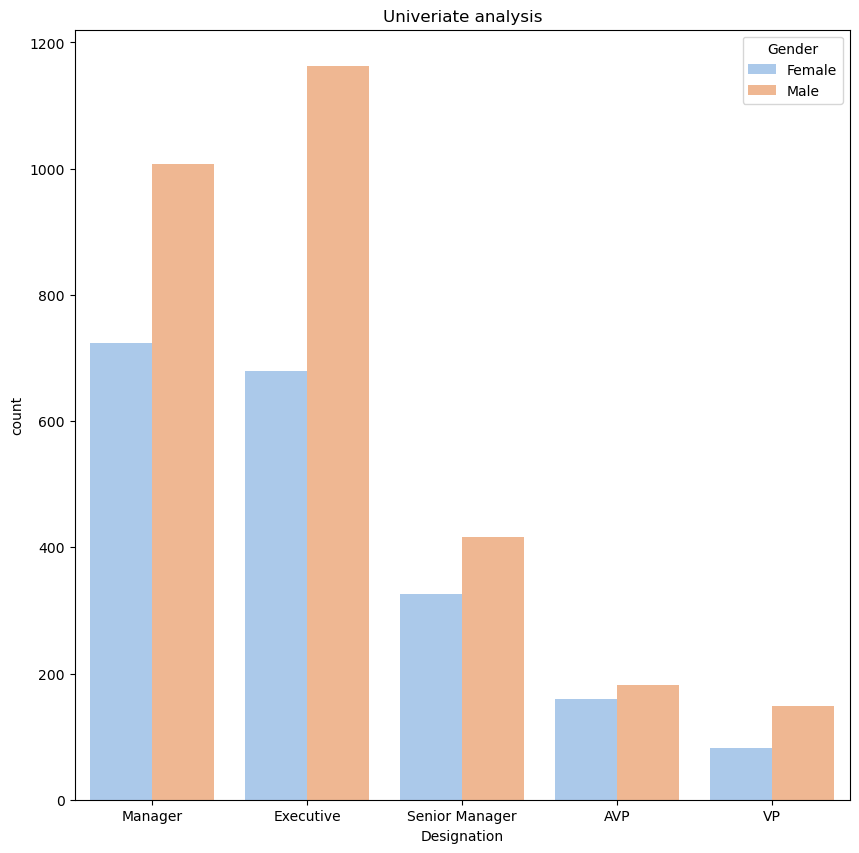

In [110]:
plt.figure(figsize= [10,10])
sns.countplot(x = 'Designation', data = df , hue= df['Gender'], palette= 'pastel')
plt.title("Univeriate analysis")
plt.xticks()
plt.yticks()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_16840\2744366119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = col, data = df , palette= 'pastel')


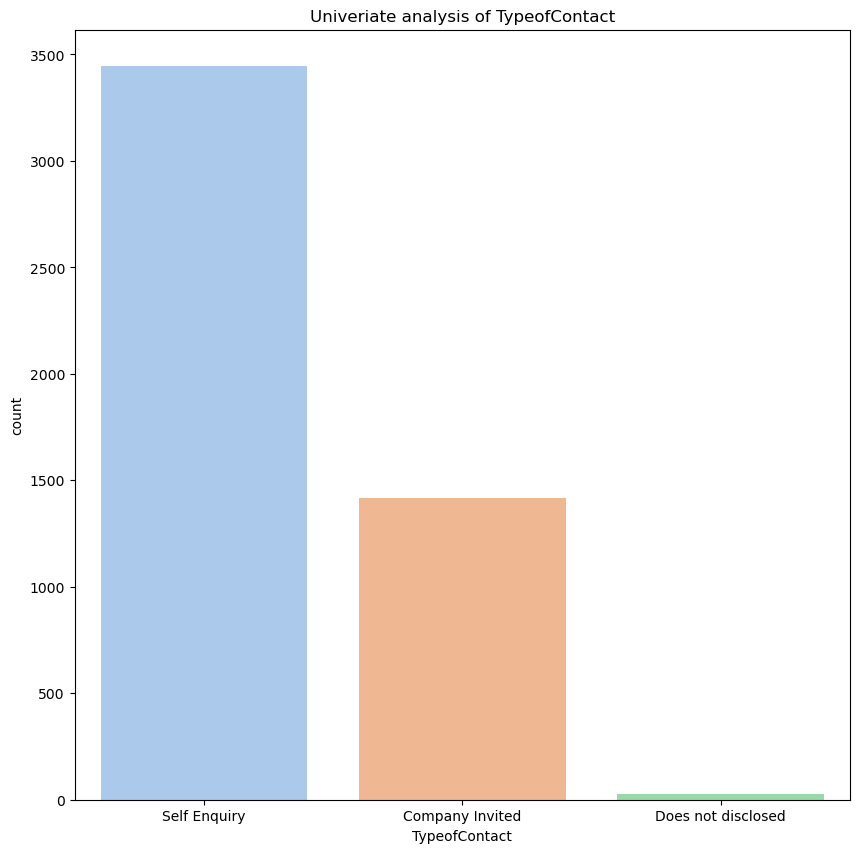

C:\Users\ACER\AppData\Local\Temp\ipykernel_16840\2744366119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = col, data = df , palette= 'pastel')


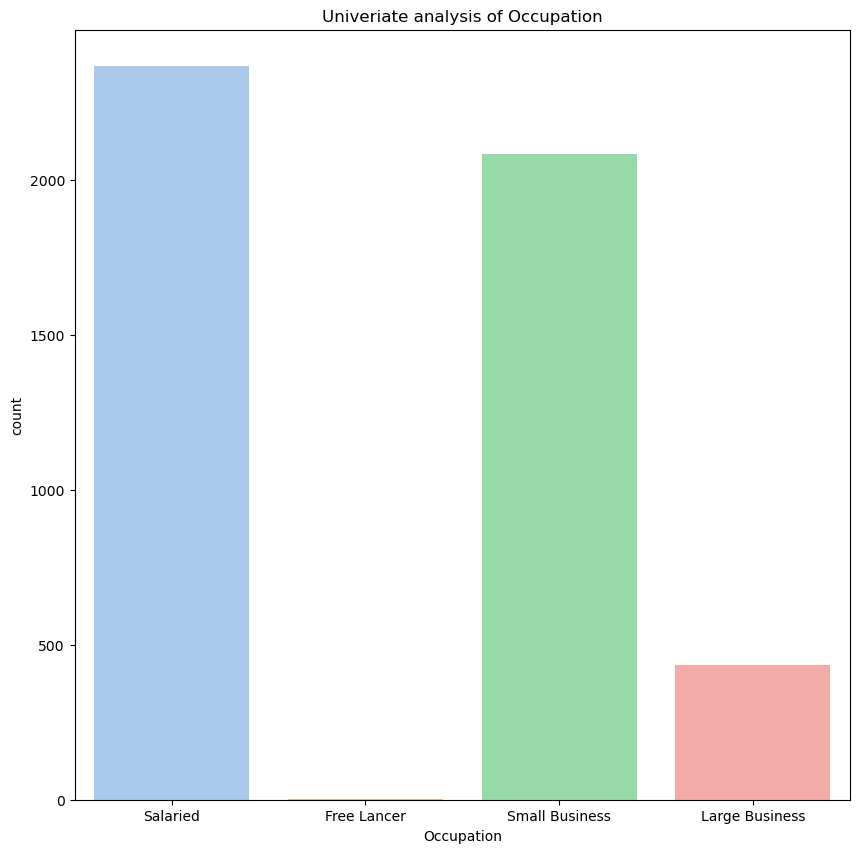

C:\Users\ACER\AppData\Local\Temp\ipykernel_16840\2744366119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = col, data = df , palette= 'pastel')


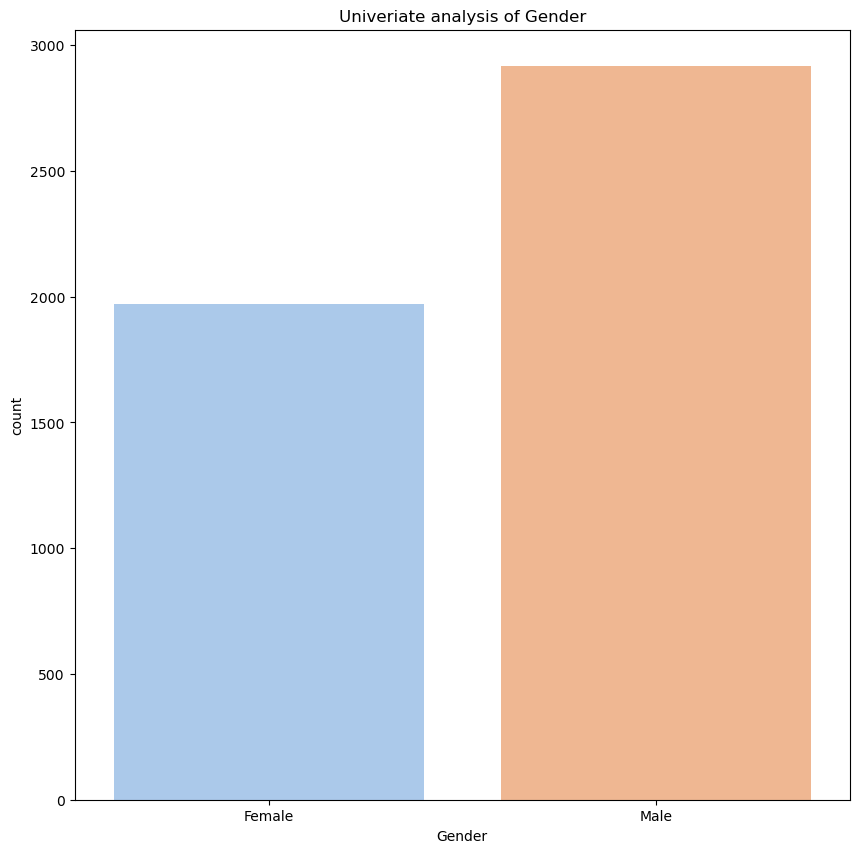

C:\Users\ACER\AppData\Local\Temp\ipykernel_16840\2744366119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = col, data = df , palette= 'pastel')


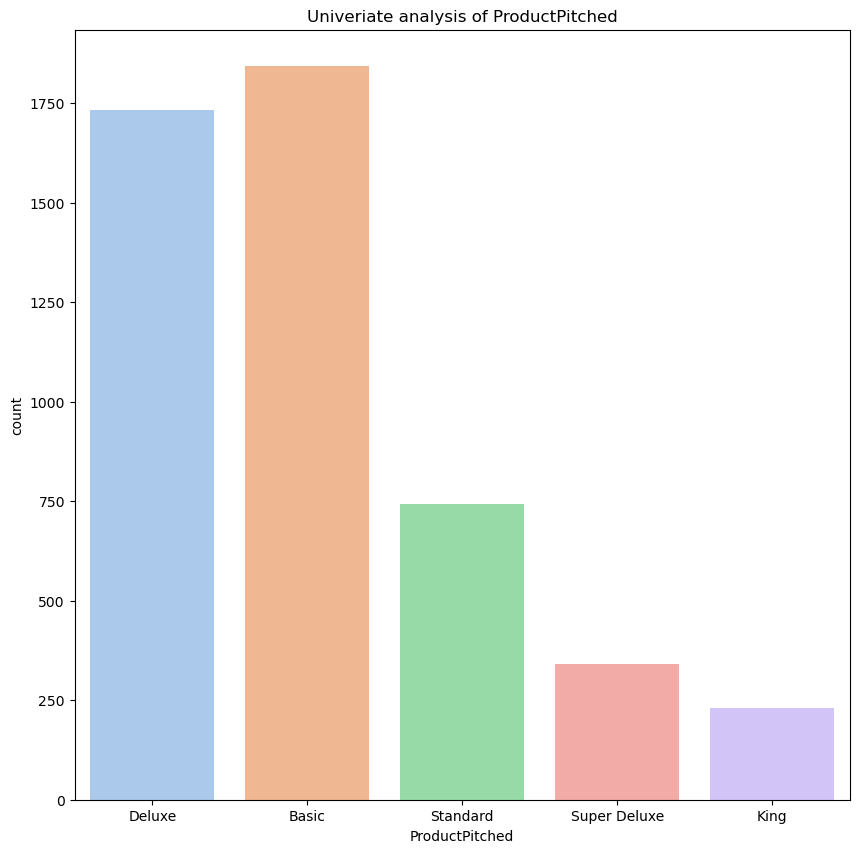

C:\Users\ACER\AppData\Local\Temp\ipykernel_16840\2744366119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = col, data = df , palette= 'pastel')


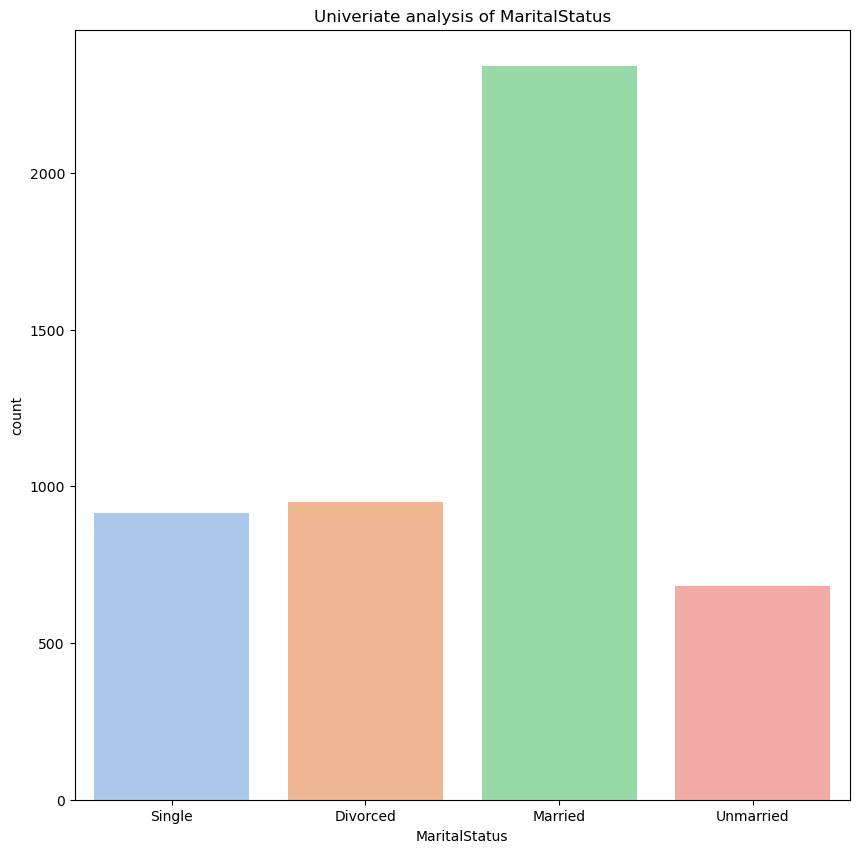

C:\Users\ACER\AppData\Local\Temp\ipykernel_16840\2744366119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = col, data = df , palette= 'pastel')


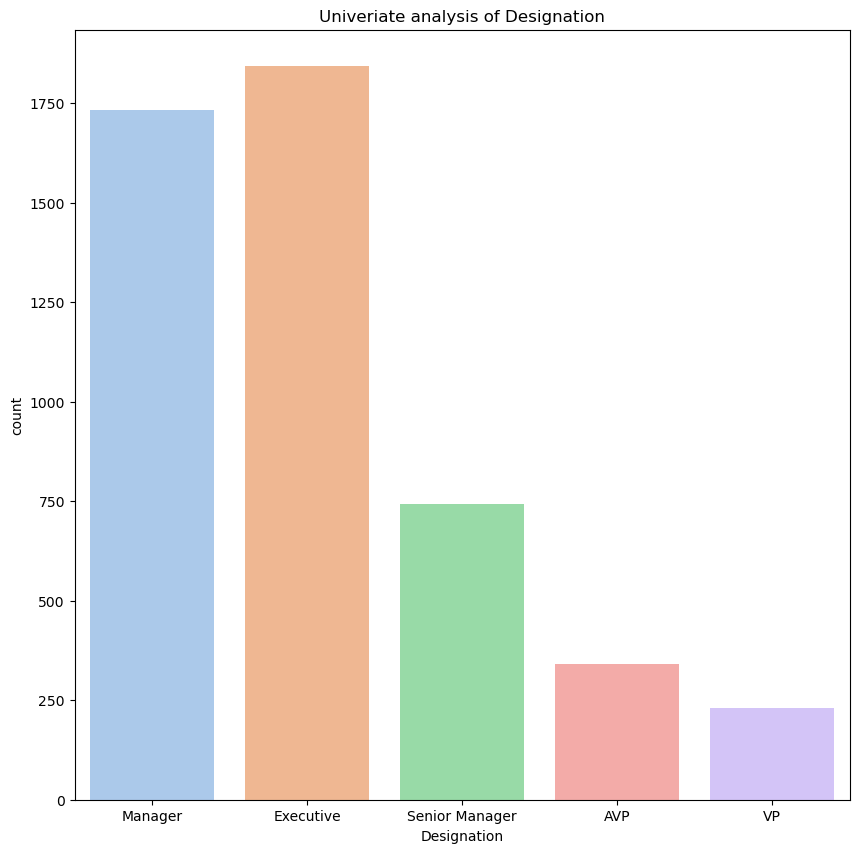

In [111]:
for col in cat_col:
    plt.figure(figsize= [10,10])
    sns.countplot(x = col, data = df , palette= 'pastel')
    plt.title(f"Univeriate analysis of {col}")
    plt.show()

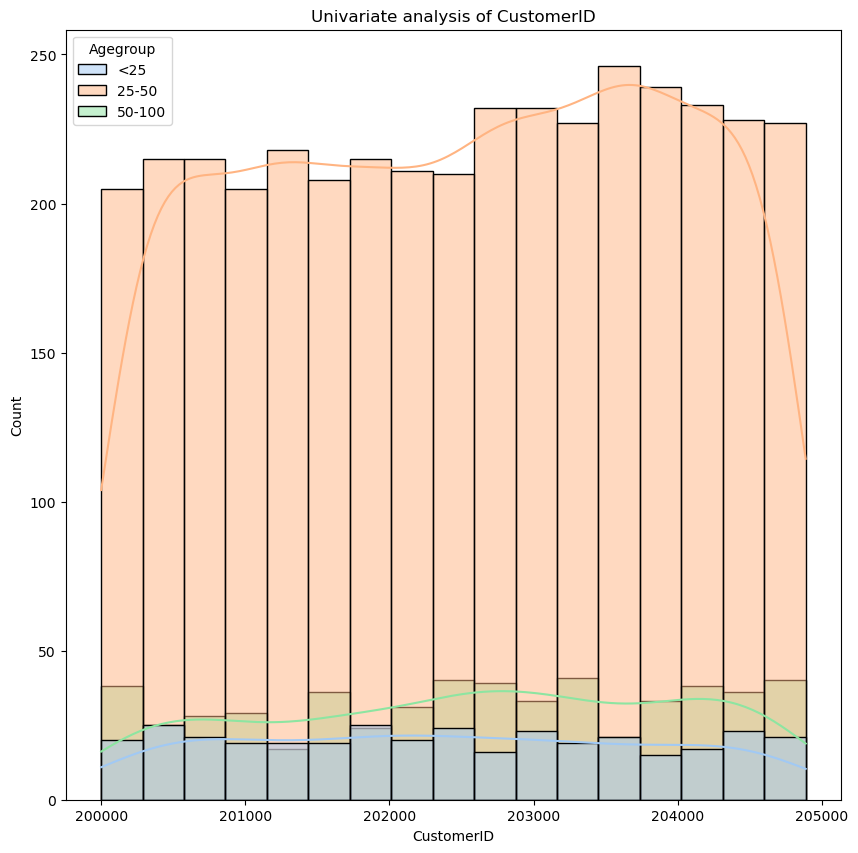

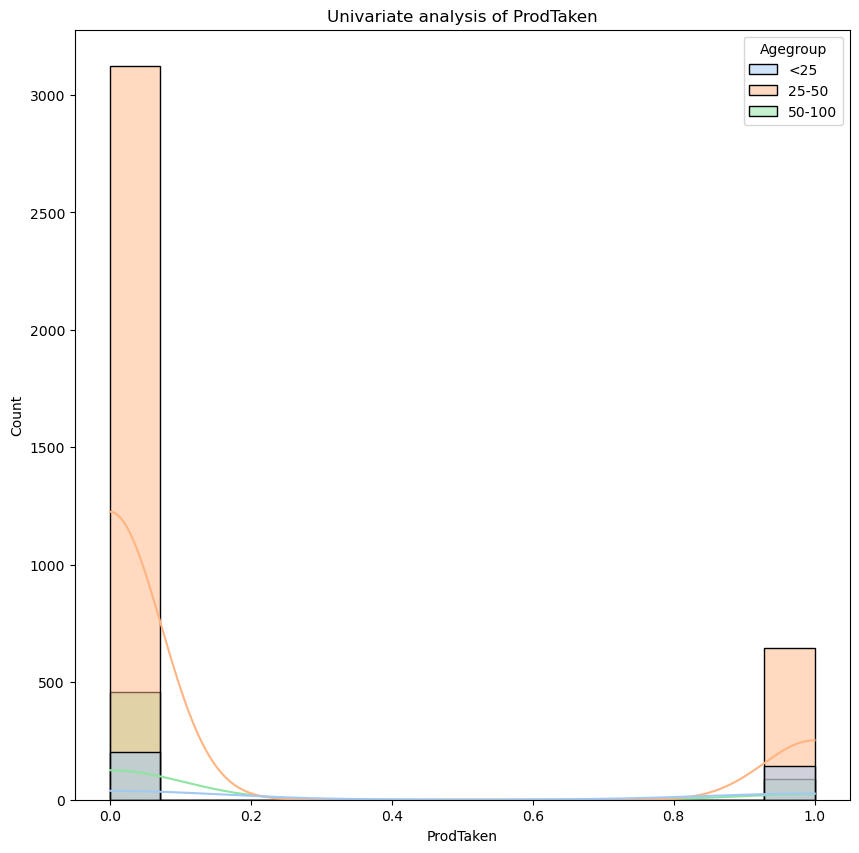

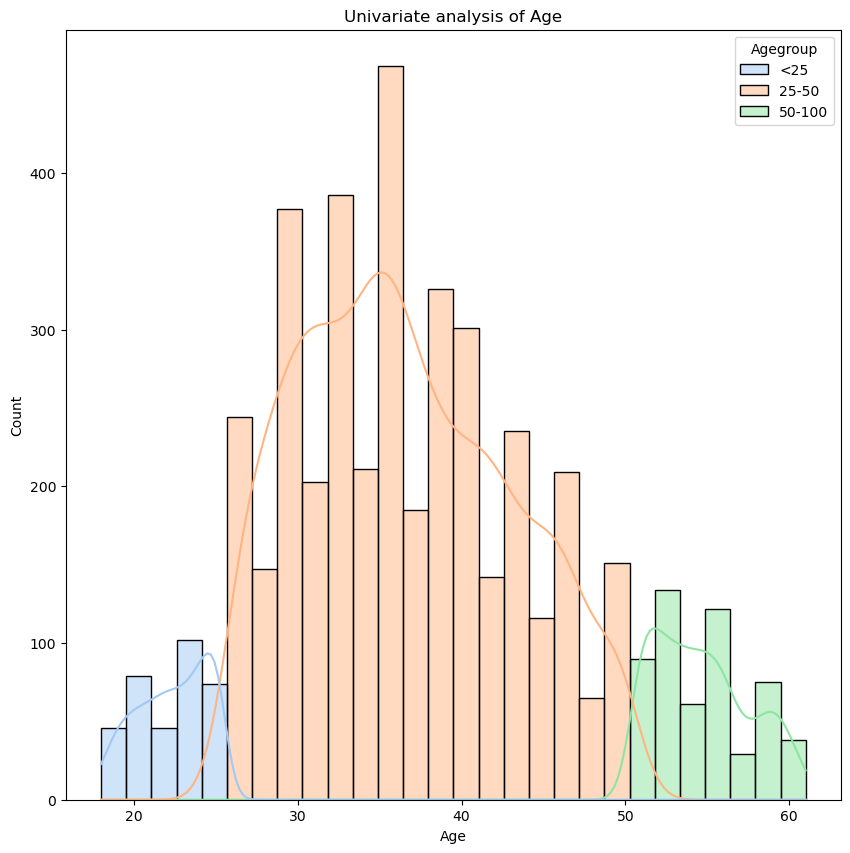

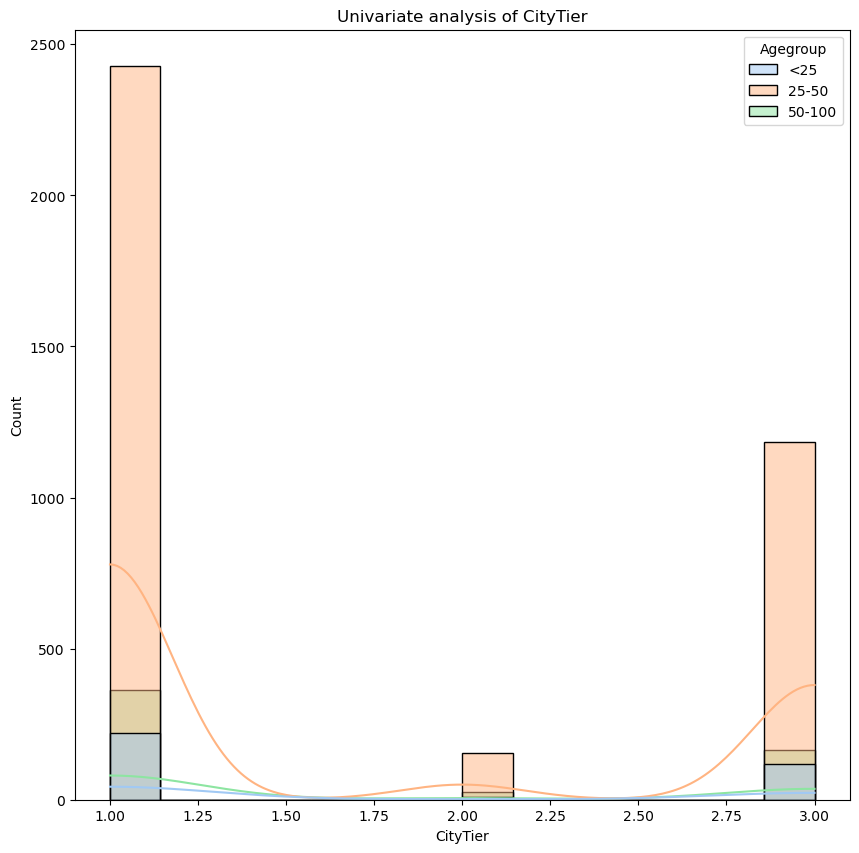

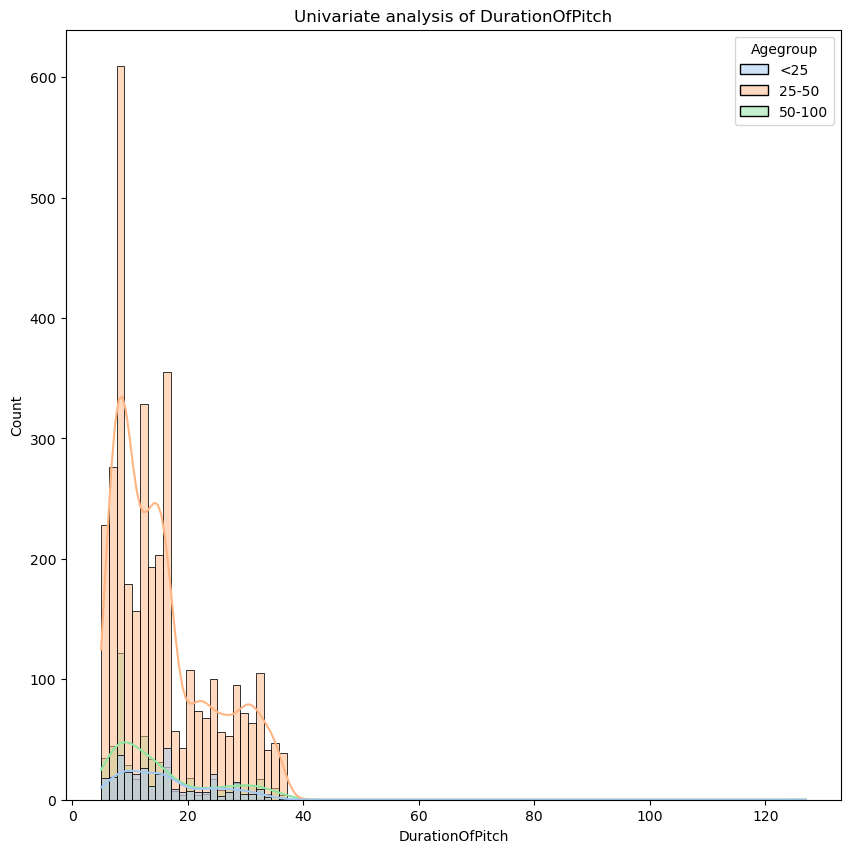

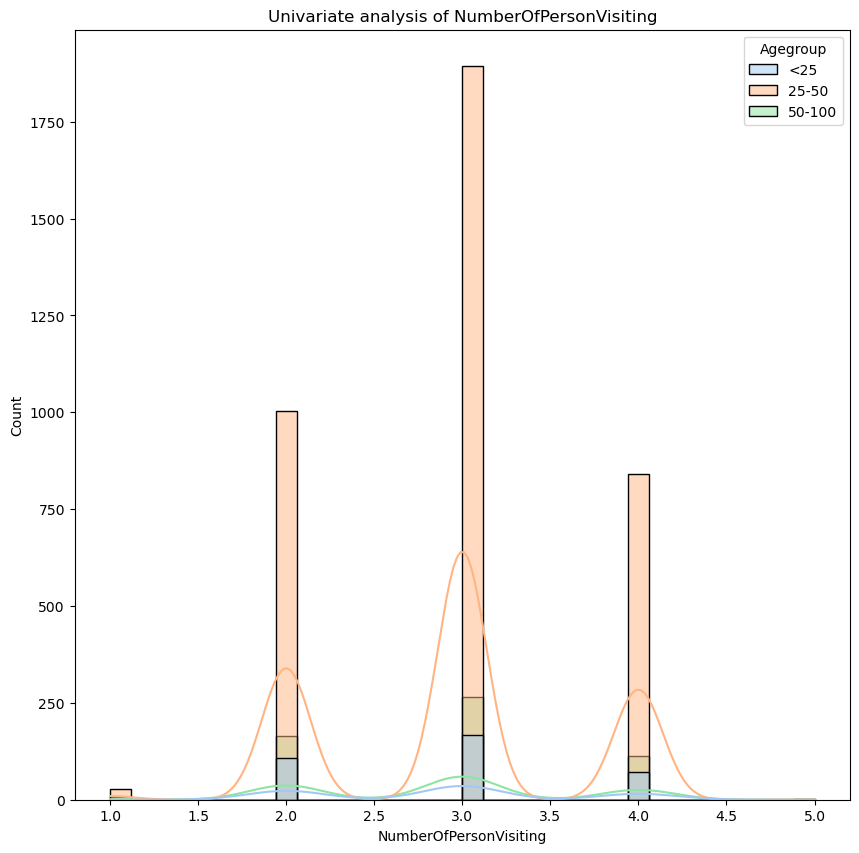

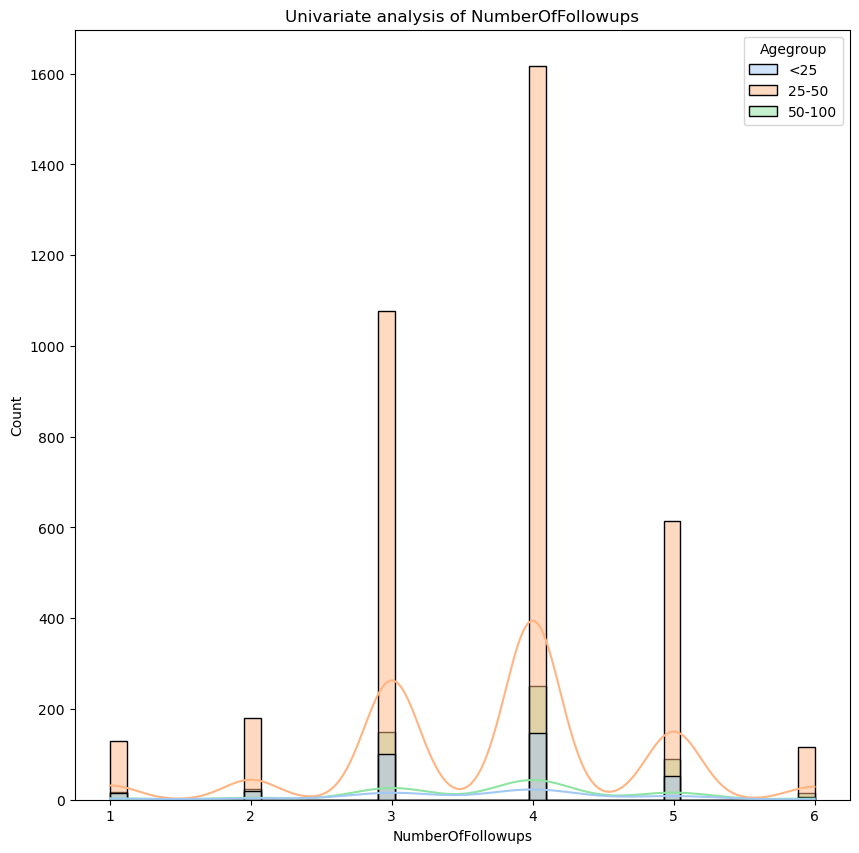

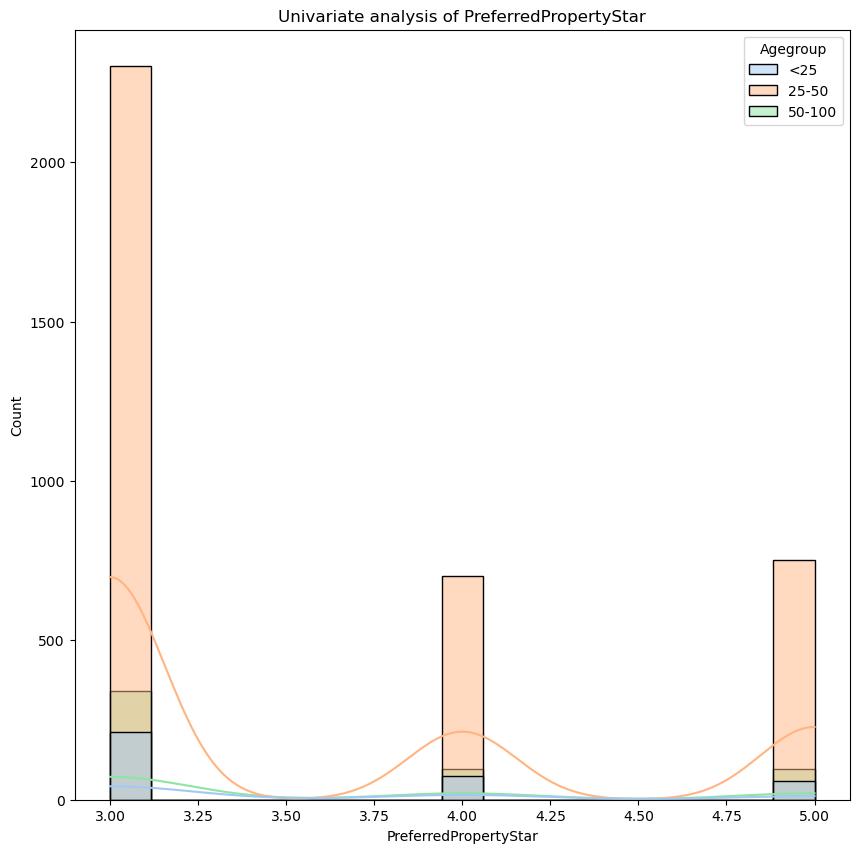

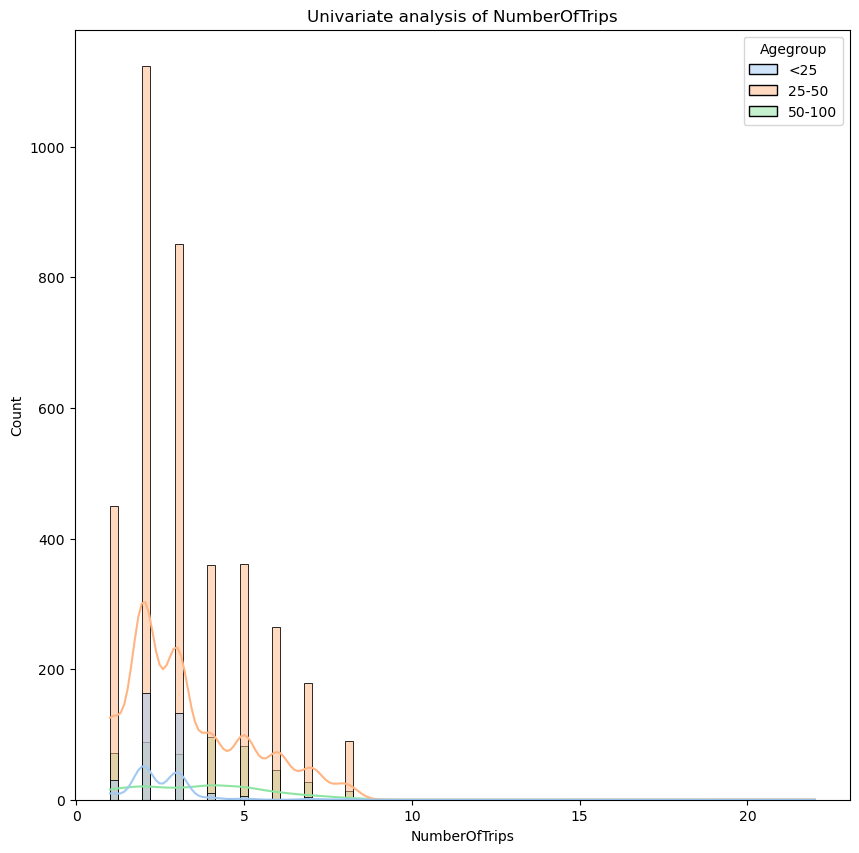

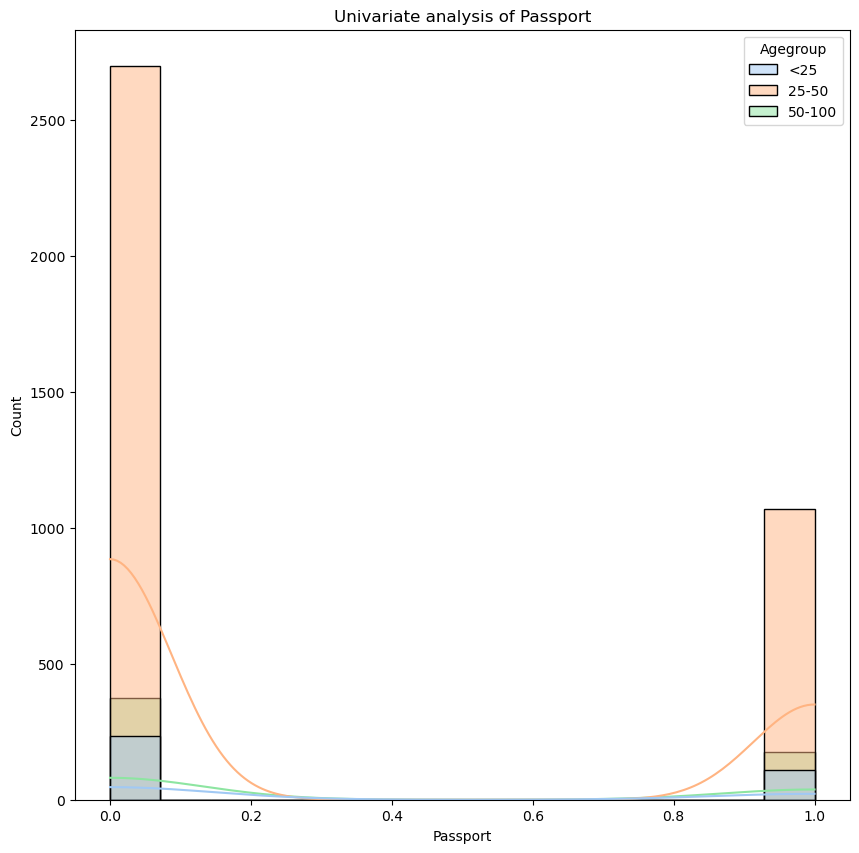

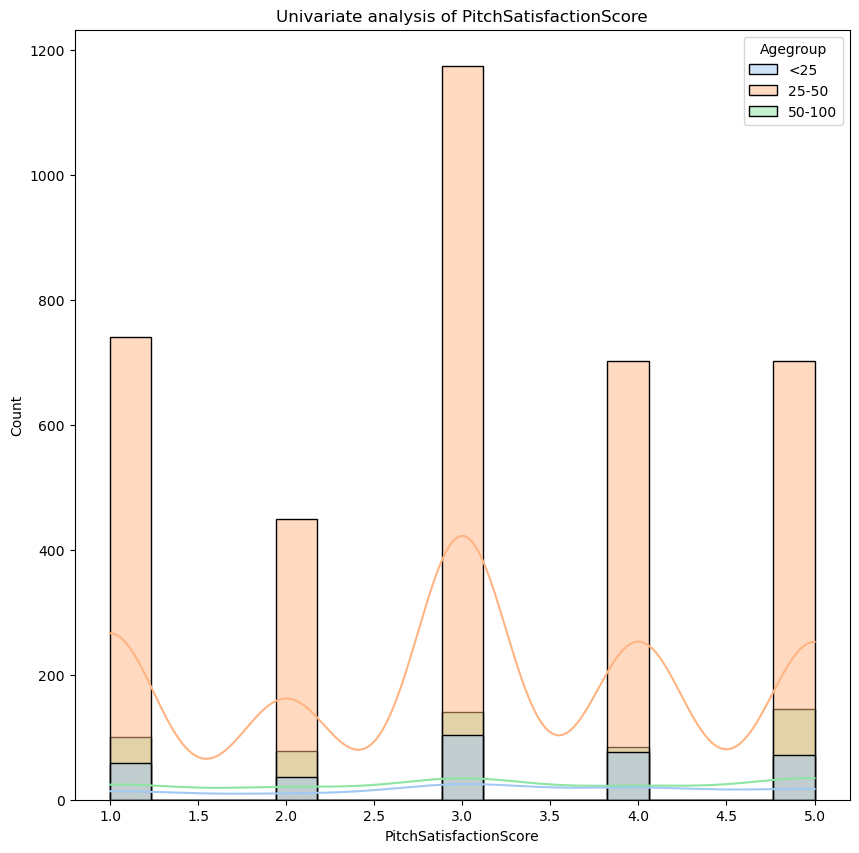

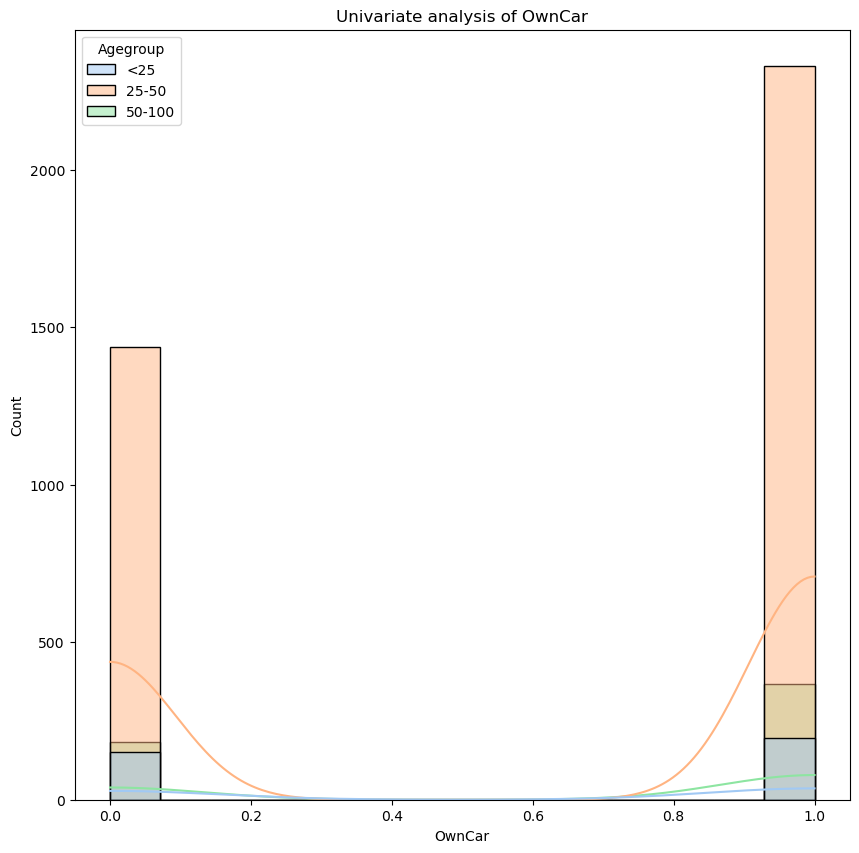

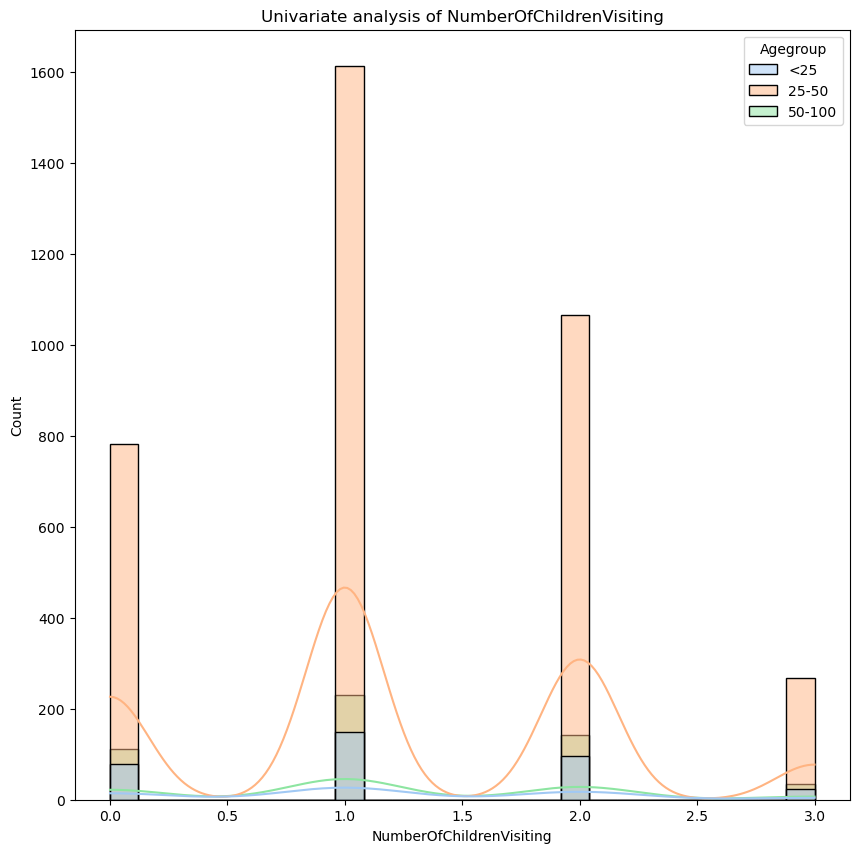

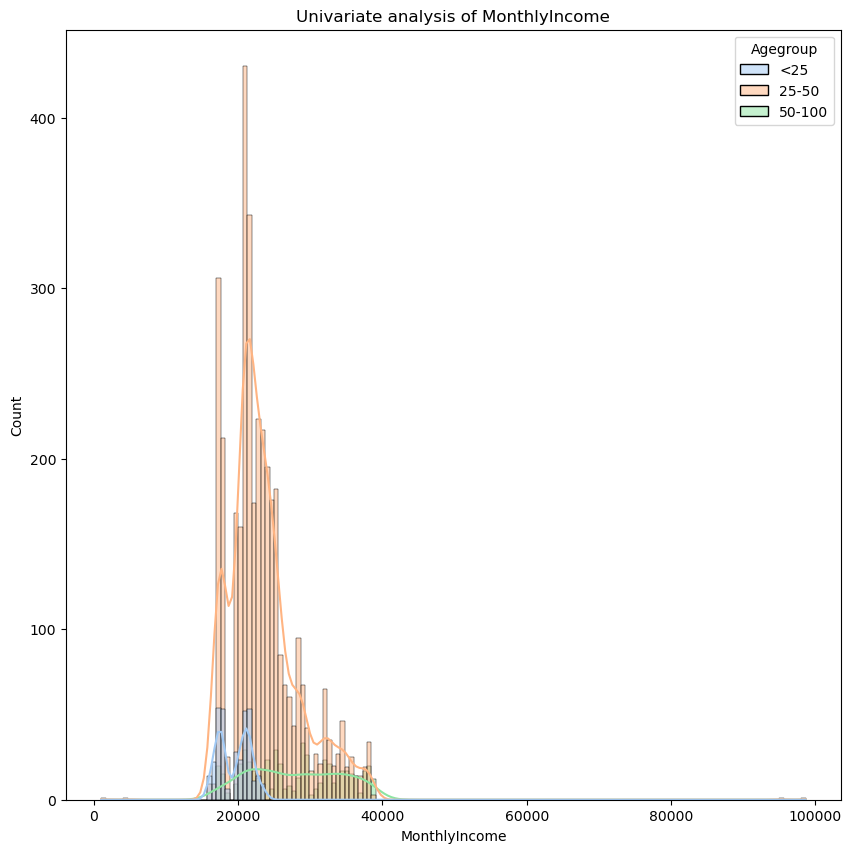

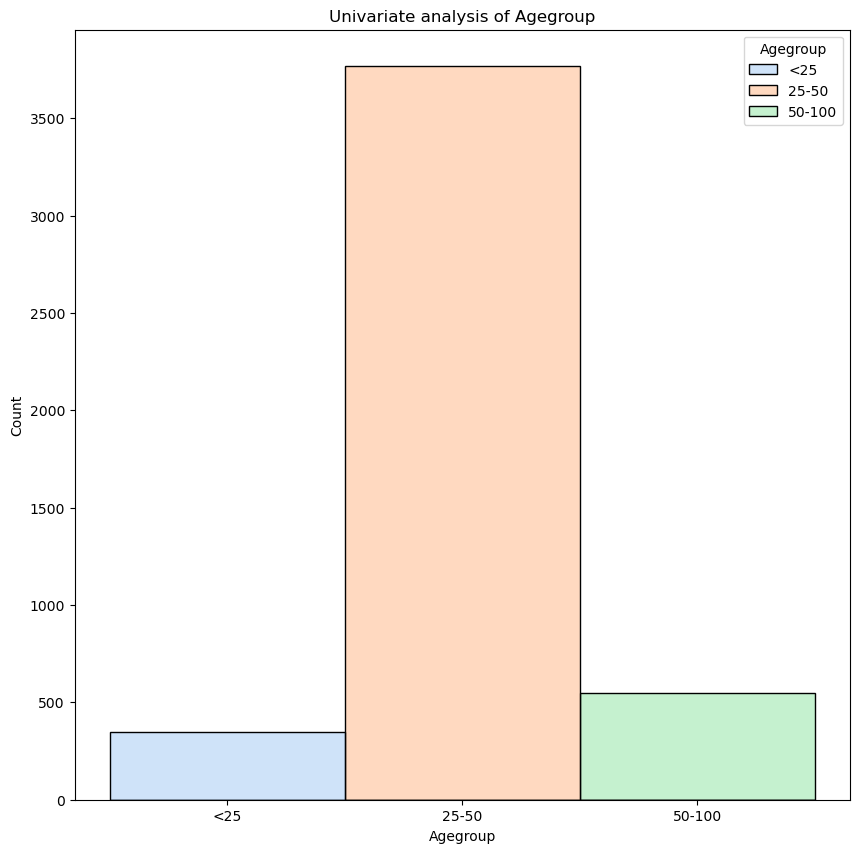

In [112]:
for num in numeric_col:
    plt.figure(figsize= [10,10])
    sns.histplot(x = num , data = df, kde = True, hue = 'Agegroup', palette= 'pastel')
    plt.title(f'Univariate analysis of {num}')
    plt.show()

In [113]:
numeric_col

['CustomerID',
 'ProdTaken',
 'Age',
 'CityTier',
 'DurationOfPitch',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'PreferredPropertyStar',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'MonthlyIncome',
 'Agegroup']

In [114]:
cat_col

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [115]:
df.Passport.unique()

array([1, 0])

##### Although passports are numeric in given data it has no value as numeric coloumn hence we convert it to object type data

In [116]:
df['Passport'] = df['Passport'].astype('object')

In [117]:
df.Passport.dtype

dtype('O')

In [118]:
for i in df.columns:
    x = df[i].unique()
    print(f'{i}: {x}')
    print()

CustomerID: [200000 200001 200002 ... 204885 204886 204887]

ProdTaken: [1 0]

Age: [41. 49. 37. 33. nan 32. 59. 30. 38. 36. 35. 31. 34. 28. 29. 22. 53. 21.
 42. 44. 46. 39. 24. 43. 50. 27. 26. 48. 55. 45. 56. 23. 51. 40. 54. 58.
 20. 25. 19. 57. 52. 47. 18. 60. 61.]

TypeofContact: ['Self Enquiry' 'Company Invited' 'Does not disclosed']

CityTier: [3 1 2]

DurationOfPitch: [  6.  14.   8.   9.  30.  29.  33.  22.  21.  32.  25.  27.  11.  17.
  15.  13.  12.  16.  10.  31.  18.  nan  24.  35.  28.  20.  26.  34.
  23.   5.  19. 126.   7.  36. 127.]

Occupation: ['Salaried' 'Free Lancer' 'Small Business' 'Large Business']

Gender: ['Female' 'Male']

NumberOfPersonVisiting: [3 2 1 4 5]

NumberOfFollowups: [ 3.  4.  2.  5. nan  1.  6.]

ProductPitched: ['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']

PreferredPropertyStar: [ 3.  4.  5. nan]

MaritalStatus: ['Single' 'Divorced' 'Married' 'Unmarried']

NumberOfTrips: [ 1.  2.  7.  5.  6.  3.  4. 19. 21.  8. nan 20. 22.]

Passport: [1 0

In [119]:
cross_tab = pd.crosstab(df.DurationOfPitch, df.ProdTaken)

<Axes: xlabel='DurationOfPitch'>

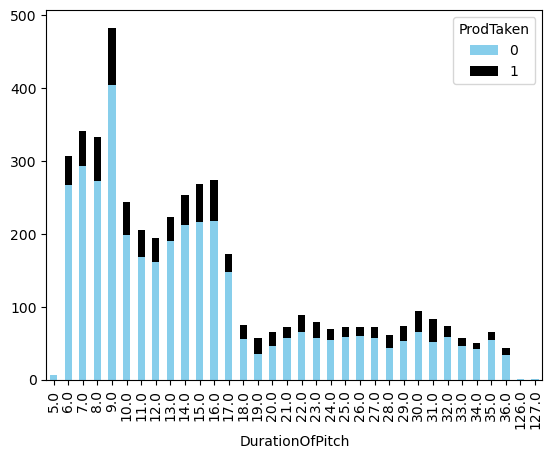

In [120]:
cross_tab.plot(kind = 'bar', stacked = True, color = ['skyblue', 'black'])

In [121]:
df.dtypes

CustomerID                     int64
ProdTaken                      int64
Age                          float64
TypeofContact                 object
CityTier                       int64
DurationOfPitch              float64
Occupation                    object
Gender                        object
NumberOfPersonVisiting         int64
NumberOfFollowups            float64
ProductPitched                object
PreferredPropertyStar        float64
MaritalStatus                 object
NumberOfTrips                float64
Passport                      object
PitchSatisfactionScore         int64
OwnCar                         int64
NumberOfChildrenVisiting     float64
Designation                   object
MonthlyIncome                float64
Agegroup                    category
dtype: object

In [122]:
df.columns

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome',
       'Agegroup'],
      dtype='object')

In [123]:
A = df[df["DurationOfPitch"] == 9]['Designation']
A.value_counts()

Designation
Executive         192
Manager           155
AVP                53
Senior Manager     52
VP                 31
Name: count, dtype: int64

#### Highest no of pakagge takers are of 9 mins duratiion of pitch so i check no of designations @9 mins call duration to gain insight that Excecutives ar emost in this bracket

In [124]:
sns.color_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

C:\Users\ACER\AppData\Local\Temp\ipykernel_16840\4059500831.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'ProductPitched', y = 'PitchSatisfactionScore', data = df, palette= 'deep' )


<Axes: xlabel='ProductPitched', ylabel='PitchSatisfactionScore'>

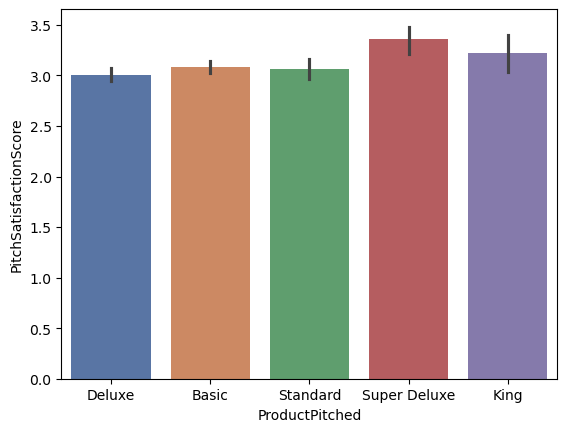

In [125]:
sns.barplot(x = 'ProductPitched', y = 'PitchSatisfactionScore', data = df, palette= 'deep' )

<Axes: xlabel='ProductPitched', ylabel='DurationOfPitch'>

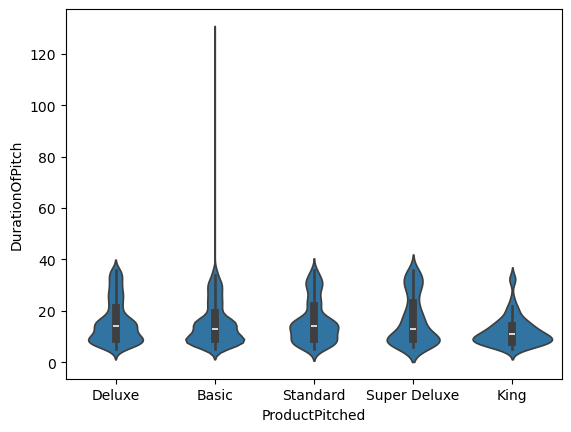

In [126]:
sns.violinplot(data = df,y = df.DurationOfPitch, x = df.ProductPitched)

c:\Users\ACER\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ACER\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 98.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ACER\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 98.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ACER\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 99.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ACER\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 98.0% of the points cann

<Axes: xlabel='DurationOfPitch', ylabel='PitchSatisfactionScore'>

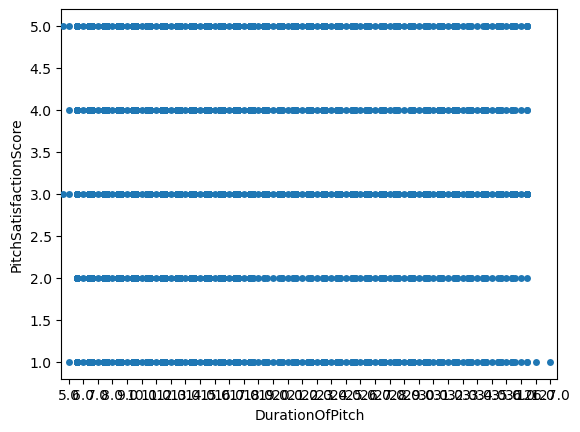

In [127]:
sns.swarmplot(data = df, x = df.DurationOfPitch, y = df.PitchSatisfactionScore)

In [128]:
## Heatmap

<Axes: >

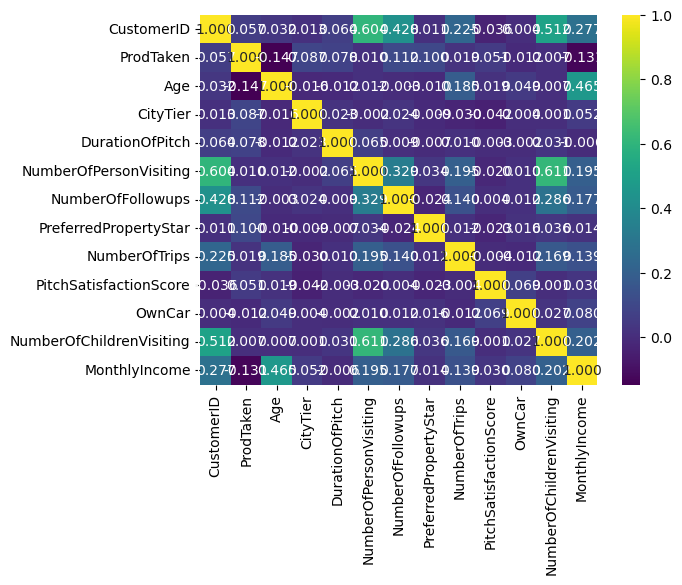

In [129]:
num_col = df.select_dtypes(include = 'number')
sns.heatmap(num_col.corr(), cmap = 'viridis', annot = True, fmt= '.3f')

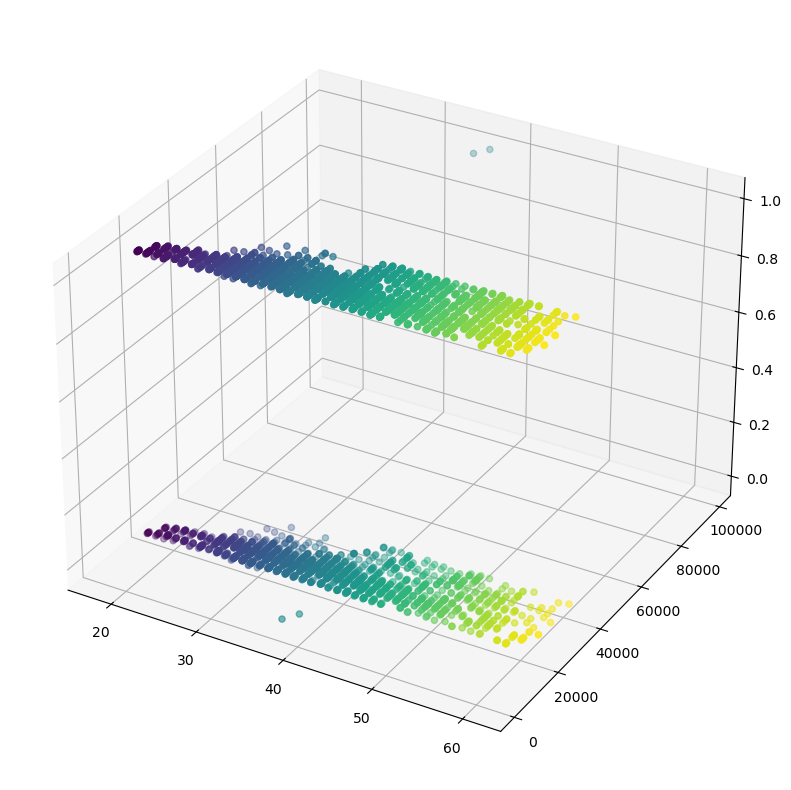

In [130]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize = [10,10])
ax = fig.add_subplot(111,projection = '3d')
ax.scatter(df['Age'], df['MonthlyIncome'],df['OwnCar'],c = df['Age'], cmap = 'viridis' )
plt.show()


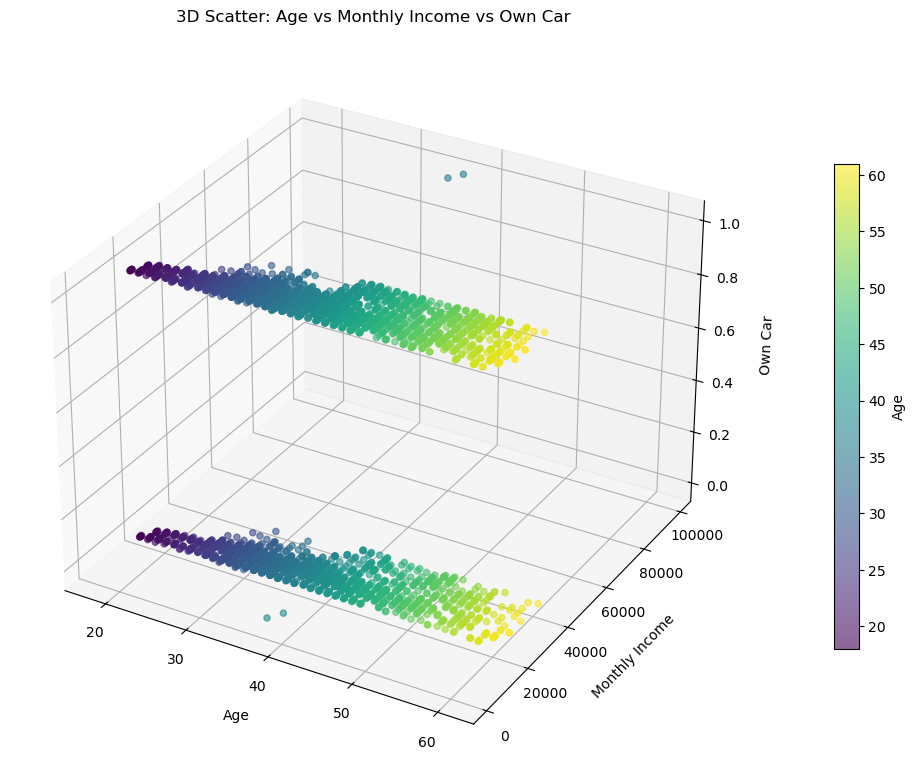

In [131]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=[10, 10])
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['MonthlyIncome'],
    df['OwnCar'],
    c=df['Age'],
    cmap='viridis',
    alpha=0.6,   # transparency for overlapping points
    s=20         # marker size
)

# Axis labels
ax.set_xlabel('Age', labelpad=10)
ax.set_ylabel('Monthly Income', labelpad=10)
ax.set_zlabel('Own Car', labelpad=10)

# Title
ax.set_title('3D Scatter: Age vs Monthly Income vs Own Car', pad=15)

# Colorbar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Age')

plt.tight_layout()
plt.show()

# Feature Engeenering


In [132]:
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,...,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,Agegroup
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,...,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0,25-50
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,...,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0,25-50
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,...,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0,25-50
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,...,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0,25-50
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,...,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,...,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0,25-50
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,...,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0,25-50
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,...,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0,50-100
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,...,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0,<25


In [133]:
df['TotalNo.Visiting'] = df.NumberOfPersonVisiting + df.NumberOfChildrenVisiting

In [134]:
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,...,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,Agegroup,TotalNo.Visiting
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,...,Single,1.0,1,2,1,0.0,Manager,20993.0,25-50,3.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,...,Divorced,2.0,0,3,1,2.0,Manager,20130.0,25-50,5.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,...,Single,7.0,1,3,0,0.0,Executive,17090.0,25-50,3.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,...,Divorced,2.0,1,5,1,1.0,Executive,17909.0,25-50,3.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,...,Divorced,1.0,0,5,1,0.0,Executive,18468.0,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,...,Unmarried,2.0,1,1,1,1.0,Manager,26576.0,25-50,4.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,...,Single,3.0,1,3,1,2.0,Executive,21212.0,25-50,6.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,...,Married,7.0,0,1,1,3.0,Senior Manager,31820.0,50-100,7.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,...,Single,3.0,0,5,0,2.0,Executive,20289.0,<25,5.0


In [135]:
df.drop('CustomerID', axis = 1 , inplace = True)

In [136]:
df

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,...,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,Agegroup,TotalNo.Visiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,...,Single,1.0,1,2,1,0.0,Manager,20993.0,25-50,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,...,Divorced,2.0,0,3,1,2.0,Manager,20130.0,25-50,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,...,Single,7.0,1,3,0,0.0,Executive,17090.0,25-50,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,...,Divorced,2.0,1,5,1,1.0,Executive,17909.0,25-50,3.0
4,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,...,Divorced,1.0,0,5,1,0.0,Executive,18468.0,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,...,Unmarried,2.0,1,1,1,1.0,Manager,26576.0,25-50,4.0
4884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,...,Single,3.0,1,3,1,2.0,Executive,21212.0,25-50,6.0
4885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,...,Married,7.0,0,1,1,3.0,Senior Manager,31820.0,50-100,7.0
4886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,...,Single,3.0,0,5,0,2.0,Executive,20289.0,<25,5.0


In [137]:
discrete_features = [i for i in df.columns if len(df[i].unique())<=5]
print(f'The number of descrete features are {len(discrete_features)}')

The number of descrete features are 15


In [138]:
discrete_features

['ProdTaken',
 'TypeofContact',
 'CityTier',
 'Occupation',
 'Gender',
 'NumberOfPersonVisiting',
 'ProductPitched',
 'PreferredPropertyStar',
 'MaritalStatus',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'Designation',
 'Agegroup']

## Here starts machine learning

In [139]:
from sklearn.model_selection import train_test_split

In [140]:
x = df.drop('ProdTaken', axis = 1)
y = df['ProdTaken']

In [141]:
x

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,Agegroup,TotalNo.Visiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0,25-50,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0,25-50,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0,25-50,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0,25-50,3.0
4,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0,25-50,4.0
4884,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0,25-50,6.0
4885,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0,50-100,7.0
4886,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0,<25,5.0


In [142]:
y

0       1
1       0
2       1
3       0
4       0
       ..
4883    1
4884    1
4885    1
4886    1
4887    1
Name: ProdTaken, Length: 4888, dtype: int64

In [143]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state= 42)

In [144]:
x_train

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,Agegroup,TotalNo.Visiting
3995,36.0,Self Enquiry,1,7.0,Small Business,Male,2,5.0,Basic,3.0,Unmarried,3.0,0,4,1,1.0,Executive,21537.0,25-50,3.0
2610,42.0,Self Enquiry,1,21.0,Salaried,Male,3,4.0,Basic,3.0,Married,6.0,0,4,1,2.0,Executive,21129.0,25-50,5.0
3083,50.0,Self Enquiry,1,7.0,Large Business,Female,3,4.0,Basic,5.0,Divorced,4.0,0,4,1,1.0,Executive,22258.0,25-50,4.0
3973,38.0,Self Enquiry,1,7.0,Salaried,Male,3,5.0,Deluxe,3.0,Married,3.0,0,5,0,1.0,Manager,24671.0,25-50,4.0
4044,44.0,Company Invited,1,35.0,Small Business,Female,4,2.0,Basic,3.0,Unmarried,6.0,0,3,0,3.0,Executive,23417.0,25-50,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,28.0,Self Enquiry,1,10.0,Small Business,Male,3,5.0,Basic,3.0,Single,2.0,0,1,1,2.0,Executive,20723.0,25-50,5.0
466,41.0,Self Enquiry,3,8.0,Salaried,Female,3,3.0,Super Deluxe,5.0,Divorced,1.0,0,5,1,1.0,AVP,31595.0,25-50,4.0
3092,38.0,Company Invited,3,28.0,Small Business,Female,3,4.0,Basic,3.0,Divorced,7.0,0,2,1,2.0,Executive,21651.0,25-50,5.0
3772,28.0,Self Enquiry,3,30.0,Small Business,Female,3,5.0,Deluxe,3.0,Married,3.0,0,1,1,2.0,Manager,22218.0,25-50,5.0


In [145]:
x_test

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome,Agegroup,TotalNo.Visiting
144,32.0,Company Invited,3,NaN,Small Business,Male,2,5.0,Deluxe,3.0,Married,1.0,0,2,0,1.0,Manager,19668.0,25-50,3.0
79,46.0,Self Enquiry,2,11.0,Small Business,Male,3,NaN,Deluxe,4.0,Married,1.0,1,5,0,1.0,Manager,20021.0,25-50,4.0
2098,37.0,Self Enquiry,3,22.0,Small Business,Male,3,4.0,Deluxe,3.0,Married,5.0,0,5,1,0.0,Manager,21334.0,25-50,3.0
4738,43.0,Self Enquiry,1,36.0,Small Business,Male,3,6.0,Deluxe,3.0,Unmarried,6.0,0,3,1,2.0,Manager,22950.0,25-50,5.0
2858,25.0,Self Enquiry,3,7.0,Large Business,Female,4,4.0,Basic,4.0,Unmarried,3.0,1,4,1,3.0,Executive,21880.0,<25,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2908,38.0,Self Enquiry,1,7.0,Large Business,Female,3,4.0,Standard,3.0,Unmarried,6.0,0,5,1,2.0,Senior Manager,26169.0,25-50,5.0
2059,29.0,Self Enquiry,1,6.0,Salaried,Female,2,4.0,Basic,5.0,Married,2.0,1,1,0,0.0,Executive,17319.0,25-50,2.0
4872,35.0,Company Invited,1,24.0,Large Business,Male,3,5.0,Basic,3.0,Married,2.0,1,5,1,2.0,Executive,27178.0,25-50,5.0
843,26.0,Does not disclosed,1,NaN,Small Business,Male,2,1.0,Basic,3.0,Divorced,2.0,0,5,1,1.0,Executive,NaN,25-50,3.0


In [146]:
y_train

3995    0
2610    0
3083    0
3973    0
4044    0
       ..
4426    0
466     0
3092    0
3772    0
860     1
Name: ProdTaken, Length: 3910, dtype: int64

In [147]:
y_test

144     0
79      0
2098    0
4738    0
2858    1
       ..
2908    0
2059    1
4872    1
843     0
2572    0
Name: ProdTaken, Length: 978, dtype: int64

In [148]:
n_features = x.select_dtypes(include= 'number').columns
n_features

Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips',
       'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting',
       'MonthlyIncome', 'TotalNo.Visiting'],
      dtype='object')

In [149]:
c_features = x.select_dtypes(exclude= 'number').columns
c_features

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Passport', 'Designation', 'Agegroup'],
      dtype='object')

### standard practice is that we do scaling for numeric features and encoding for categorical features

In [150]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
#ColumnTransformer applies transformations to columns of an array or pandas datafarme


In [151]:
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

In [152]:
preprocessor = ColumnTransformer(
    [
         ('OneHotEncoder', oh_transformer,c_features),
            ('StandardScaler',numeric_transformer,n_features)

    ])

In [153]:
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Passport', 'Designation', 'Agegroup'],
      dtype='object')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips',
       'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting',
       'MonthlyIncome', 'TotalNo.Visiting'],
      dtype='object'))])

In [154]:
x_train = preprocessor.fit_transform(x_train)
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,-1.010449,-1.252472,1.281917,-0.728549,-0.129586,0.679690,0.782966,-0.219705,-0.384685,-0.769590
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.655625,0.129347,0.283956,-0.728549,1.487116,0.679690,0.782966,0.946606,-0.460461,0.640106
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,-1.010449,0.129347,0.283956,1.764293,0.409315,0.679690,0.782966,-0.219705,-0.250777,-0.064742
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,-1.010449,0.129347,1.281917,-0.728549,-0.129586,1.408395,-1.277194,-0.219705,0.197377,-0.064742
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,2.321700,1.511165,-1.711966,-0.728549,1.487116,-0.049015,-1.277194,2.112917,-0.035522,2.049802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,-0.653433,0.129347,1.281917,-0.728549,-0.668486,-1.506426,0.782966,0.946606,-0.535865,0.640106
3906,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,-0.891444,0.129347,-0.714005,1.764293,-1.207387,1.408395,0.782966,-0.219705,1.483337,-0.064742
3907,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,1.488663,0.129347,0.283956,-0.728549,2.026017,-0.777720,0.782966,0.946606,-0.363512,0.640106
3908,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.726673,0.129347,1.281917,-0.728549,-0.129586,-1.506426,0.782966,0.946606,-0.258206,0.640106


In [155]:
preprocessor.transform(x_test)

array([[ 1.        ,  0.        ,  0.        , ..., -0.2197046 ,
        -0.73180503, -0.76959002],
       [ 0.        ,  0.        ,  1.        , ..., -0.2197046 ,
        -0.6662441 , -0.06474213],
       [ 0.        ,  0.        ,  1.        , ..., -1.38601522,
        -0.42238716, -0.76959002],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.94660603,
         0.6629898 ,  0.64010577],
       [ 0.        ,  1.        ,  0.        , ..., -0.2197046 ,
                nan, -0.76959002],
       [ 0.        ,  0.        ,  1.        , ...,  2.11291665,
        -0.44708859,  2.04980155]])